# Instrument Systematics Example

This notebook shows a concrete example of `instrument` systematic retrieval in a notebook. The example relies on the JWST transit data of WASP-39b NIRSpec-G395H, published in Carter et al. 2024, Nat. Ast. 8, pages 1008–1019. The data is available at: https://doi.org/10.5281/zenodo.10161743

Additionally, the Instrument Line Shape functions are required. These are available at STScI: https://jwst-crds.stsci.edu/

In the example, we setup a basic retrieval for this data and show how instrument systematics can be accounted for.

In [1]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
import _shared

_shared = importlib.reload(_shared)
build_transmission_model = _shared.build_transmission_model
## Enable if you need the opacity data.
#_shared.ensure_opacity_data(download=True)

# Use a coarse setup so the documentation notebook runs quickly.
context = build_transmission_model(
    include_cia=False,
    include_rayleigh=False,
    download=False,
    nlayers=40,
 )
tm = context['tm']

Numba not installed, using numpy instead


In [2]:
tm.build()

In [3]:
out = tm.model()

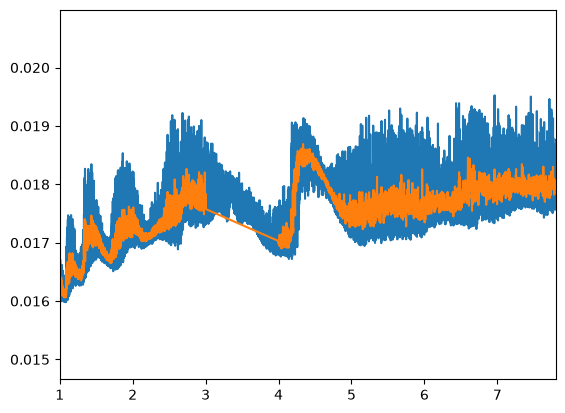

In [4]:
## EXAMPLE OF A BIN DOWN TO R = 15k and apply of WAVE SHIFT

from taurex.util.util import create_grid_res
RES = 15000
high_res_grid1 = create_grid_res(RES, 1, 3)
high_res_grid2 = create_grid_res(RES, 3, 7.8)
from taurex.binning import FluxBinnerConv
fb = FluxBinnerConv(wlgrids= [high_res_grid1[:,0], high_res_grid2[:,0]],
        wlgrid_widths= [high_res_grid1[:,1], high_res_grid2[:,1]],
        broadening_type= 'polynomial',
        wlshift = [0, 1],
        max_wlbroadening = 0.1,
        broadening_coeffs=[[3000, 10], [3000]], ## These are the polynomial parameters.
        broadening_basis = "resolution_poly",
        factor_cut = 5,
        wlres = RES,)

x = fb.bindown(out[0], out[1])

plt.figure()
plt.plot(10000/out[0], out[1])
plt.plot(x[0], x[1])
plt.xlim(1, 7.8)
plt.show()

### WAVE SHIFT NOT WORKING YET!

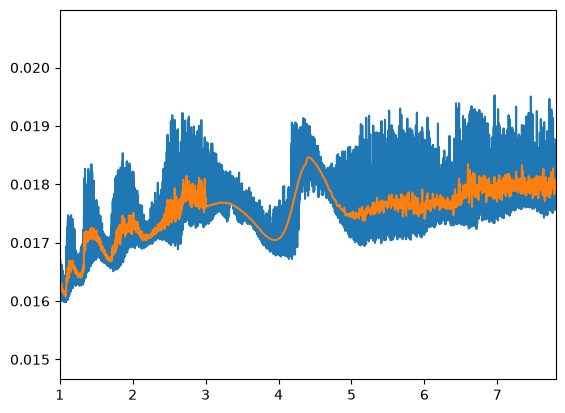

In [6]:
### Now using real profiles

from taurex.util.util import create_grid_res
RES = 50000
high_res_grid1 = create_grid_res(RES, 1, 3)
high_res_grid2 = create_grid_res(RES, 3, 7.8)
from taurex.binning import FluxBinnerConv
fb = FluxBinnerConv(wlgrids= [high_res_grid1[:,0], high_res_grid2[:,0]],
        wlgrid_widths= [high_res_grid1[:,1], high_res_grid2[:,1]],
        broadening_profiles = ['../tmp/InstrumentFiles/jwst_nirspec_g395h_disp.fits', 
                                                   '../tmp/InstrumentFiles/jwst_nirspec_g395h_disp.fits'],
        broadening_type = "stsci_fits",
        wlshift = [0, 0.2],
        max_wlbroadening = 0.1,
        broadening_coeffs=[[0], [-3000]], ## These are the polynomial parameters.
        broadening_basis = "resolution_poly",
        factor_cut = 5,
        wlres = RES,)

x = fb.bindown(out[0], out[1])

plt.figure()
plt.plot(10000/out[0], out[1])
plt.plot(x[0], x[1])
plt.xlim(1, 7.8)
plt.show()

In [6]:
from taurex.data.spectrum import OffsetSpectraCont
obs = OffsetSpectraCont(path_spectra=['../tmp/spectra/wasp39b_NRS1_Carter2024.txt', 
                                           '../tmp/spectra/wasp39b_NRS2_Carter2024.txt'],
                            path_broadening = ['../tmp/InstrumentFiles/jwst_nirspec_g395h_disp.fits', 
                                                   '../tmp/InstrumentFiles/jwst_nirspec_g395h_disp.fits'],
                            max_wlbroadening=0.003, wlres=15000,
                            factor_cut=3, broadening_order=0,)

In [6]:
obs.broadening_coeffs[0][0] = 0
inst_binner = obs.create_binner()
out_bin = inst_binner.bindown(out[0], out[1])

In [7]:
obs.broadening_coeffs

[array([0.]), array([0.])]

<>:11: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:11: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/4c/xrxpgpxj13s56gybbsqrpp4w0000gn/T/ipykernel_3994/348010052.py:11: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.xlabel('Wavelength ($\mu$m)')


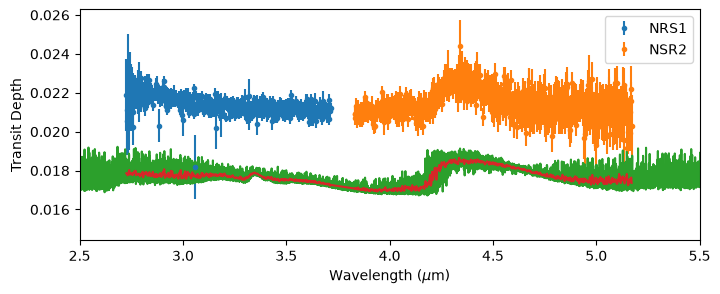

In [8]:
plt.figure(figsize=(8,3))
plt.errorbar(obs._raw[0][:,0],obs._raw[0][:,1], yerr=obs._raw[0][:,2], fmt='.', label='NRS1')
plt.errorbar(obs._raw[1][:,0],obs._raw[1][:,1], yerr=obs._raw[1][:,2], fmt='.', label='NSR2')
plt.plot(10000/out[0], out[1])

plt.plot(out_bin[0], out_bin[1])

plt.xlim(2.5, 5.5)

plt.legend()
plt.xlabel('Wavelength ($\mu$m)')
plt.ylabel('Transit Depth')
plt.show()

In [9]:
from taurex.optimizer import NestleOptimizer

In [10]:
from taurex.optimizer.nestle import NestleOptimizer

opt = NestleOptimizer(num_live_points=50, tol=30.0)
opt.set_model(tm)
opt.set_observed(obs)

opt.enable_fit('Offset_1')
opt.set_boundary('Offset_1', [-1e-2, 1e-2])

opt.enable_fit('EScale_1')
opt.set_boundary('EScale_1', [0.8, 5])

opt.enable_fit('EScale_2')
opt.set_boundary('EScale_2', [0.8, 5])

opt.enable_fit('Broadening_1_0')
opt.set_boundary('Broadening_1_0', [-0.35, 0.35])

opt.enable_fit('Broadening_2_0')
opt.set_boundary('Broadening_2_0', [-0.35, 0.35])

opt.enable_fit('T')
opt.set_boundary('T', [300, 3000])

opt.enable_fit('H2O')
opt.set_boundary('H2O', [1e-12, 0.1])

opt.enable_fit('CO2')
opt.set_boundary('CO2', [1e-12, 0.1])

opt.enable_fit('planet_radius')
opt.set_boundary('planet_radius', [0.5, 2])

In [11]:
res = opt.fit()

it=   878 logz=7313.535909niter: 879
ncall: 4849
nsamples: 929
logz: 7339.883 +/-  0.645
h: 20.810


In [12]:
for solution,optimized_map,optimized_value,values in opt.get_solution():
    opt.update_model(optimized_map)

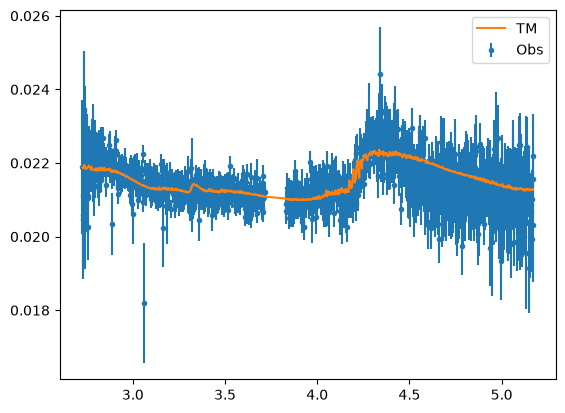

In [13]:
plt.figure()
plt.errorbar(obs.wavelengthGrid,obs.spectrum,obs.errorBar, fmt='.', label='Obs')
plt.plot(obs.wavelengthGrid,inst_binner.bin_model(tm.model(obs.wavenumberGrid))[1],label='TM', zorder=10)
plt.legend()
plt.show()